In [80]:
from pyparsing import makeXMLTags
from sklearn.datasets import make_blobs

X,y = make_blobs(
    n_features=2,
    n_samples=500,
    centers=4,
    cluster_std=1.8,
    shuffle=True,
    random_state=42,
)

In [81]:
import numpy as np
import pandas as pd

X = np.transpose(X)


df  = pd.DataFrame({
    "f1": X[0],
    "f2": X[1],
    "cluster":y
})

In [82]:
df.head()

,f1,f2,cluster
0,-6.769636,6.057805,3
1,-11.734023,-6.977840,2
2,8.581524,0.518233,1
3,-3.214992,6.379959,0
4,-4.717442,-7.614645,2


In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   f1       500 non-null    float64
 1   f2       500 non-null    float64
 2   cluster  500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB


In [84]:
df.describe()

,f1,f2,cluster
count,500.000000,500.000000,500.000000
mean,-3.385847,2.919105,1.500000
std,5.477677,6.545300,1.119154
min,-11.734023,-10.860153,0.000000
25%,-7.825499,-2.148939,0.750000
50%,-4.778204,4.611997,1.500000
75%,1.016533,8.423057,2.250000
max,10.181864,15.949203,3.000000


In [85]:
from sklearn.mixture import GaussianMixture


mixture = GaussianMixture(n_components=4 , random_state=42)


In [86]:
mixture.fit(df[["f1","f2"]])

,"n_components n_components: int, default=1The number of mixture components.",4
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [87]:
df['predicted'] = mixture.predict(df[["f1","f2"]])

In [88]:
df.head()

,f1,f2,cluster,predicted
0,-6.769636,6.057805,3,1
1,-11.734023,-6.977840,2,2
2,8.581524,0.518233,1,0
3,-3.214992,6.379959,0,3
4,-4.717442,-7.614645,2,2


In [89]:
from sklearn.metrics import silhouette_score,adjusted_rand_score

silhouette = silhouette_score(df[["f1","f2"]] , df['predicted'])
rand_score = adjusted_rand_score(df['cluster'],df['predicted'])

In [90]:
print("Silhouette Score: ",silhouette)
print("Adjusted Rand Score: ",rand_score)

Silhouette Score:  0.6277074237272473
Adjusted Rand Score:  0.9532829865640792


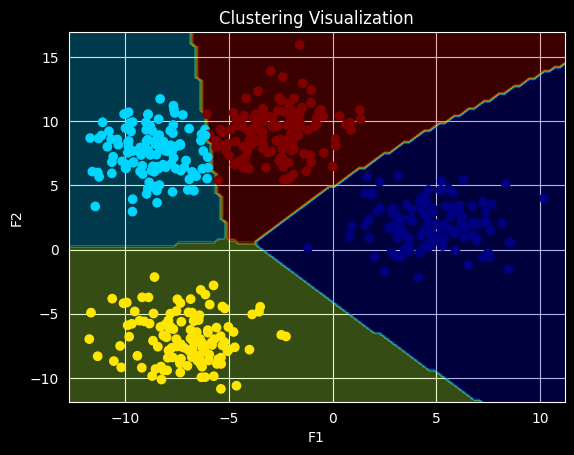

In [91]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay


plt.figure(figsize=(10,10))
DecisionBoundaryDisplay.from_estimator(
    mixture , df[[ "f1","f2"]] , response_method='predict' ,cmap='jet',alpha=0.3
)
plt.scatter(df['f1'],df['f2'], c=df['predicted'] , cmap='jet')
plt.xlabel("F1")
plt.ylabel("F2")
plt.title("Clustering Visualization")
plt.show()

In [92]:
probabs = mixture.predict_proba(df[["f1","f2"]])

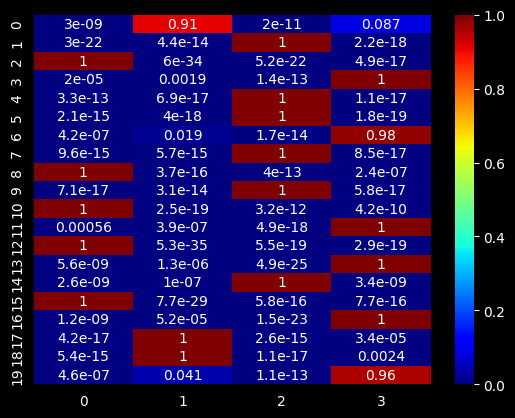

In [93]:
import seaborn as sns

sns.heatmap(probabs[:20], annot=True, cmap='jet')